# Dyakonov **and** Dyakonov–Voigt waves at the same interface

Mackay, Zhou & Lakhtakia (2019), Proc. R. Soc. A **475**: 20190317.
Uniaxial $\mathcal A$ ($z>0$, optic axis $\parallel x$) over isotropic $\mathcal B$ ($z<0$); parameters $(\varepsilon_A^s,\varepsilon_A^t,\varepsilon_B)=(1.5,6,2)$.

* **Dyakonov** (eq. 2.27): a dispersion relation in $q$ — solved for $q/k_0$ vs $\psi$, giving a continuous branch.
* **Dyakonov–Voigt** (eq. 2.29): contains **no $q$** — it fixes the single propagation angle $\psi_{\rm DV}$ (per quadrant); the wavenumber then follows from eq. 2.14, $q/k_0=\sqrt{\varepsilon_A^s}\,\sec\psi$.

So the DV "curve" is a single point, and we overlay it on the Dyakonov branch.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from bruggeman import eps_hcm
#eps_t_br, eps_z_br  = eps_hcm(1.5, 5.0, fA=0.5, shape="dt_spheroid", kappa=0.9, alpha=0.3)
#eps_s, eps_t = eps_z_br.real, eps_t_br.real
#eps_B = 2.0
eps_s, eps_t, eps_B = 1.5, 6, 2.0   

## 1. Dyakonov branch — eq. (2.27)

Normalised, corrected (leading minus) dispersion residual. It is real-valued for a bound wave.
Equation (2.27) is *also* satisfied identically along the **DV singular locus** $q/k_0=\sqrt{\varepsilon_A^s}\sec\psi$ (where $\alpha_{A1}=\alpha_{A2}$). Rather than filter that spurious root by a tolerance, we **deflate** the residual — divide out the known factor $(q/k_0-\sqrt{\varepsilon_A^s}\sec\psi)$ — leaving only the genuine Dyakonov root. (Verified below that the locus is an exact root, so the division is legitimate.)

In [2]:
def residual(qt, psi):
    """Real residual of the corrected eq. (2.27); qt=q/k0, psi in radians."""
    aA1 = 1j*np.sqrt(complex(qt**2 - eps_s))
    arg = (qt**2*(eps_s+eps_t-(eps_s-eps_t)*np.cos(2*psi)) - 2*eps_s*eps_t)/(2*eps_s)
    aA2 = 1j*np.sqrt(complex(arg)); aB = -1j*np.sqrt(complex(qt**2 - eps_B))
    L = -eps_s*(eps_s*aB - eps_B*aA1)*(aB - aA2)*np.tan(psi)**2
    R =  aA1*(aB - aA1)*(eps_s*aB*aA2 - eps_B*aA1**2)
    return (L - R).real

def qmin(psi):
    B = eps_s+eps_t-(eps_s-eps_t)*np.cos(2*psi)
    return np.sqrt(max(eps_s, eps_B, 2*eps_s*eps_t/B))

def q_DV_line(psi):
    "DV singular locus (eq. 2.14): q/k0 = sqrt(eps_s) sec(psi)."
    return np.sqrt(eps_s)/np.cos(psi)

def dyakonov_q(psi, n=4000):
    "Genuine Dyakonov q/k0 via a deflated residual (spurious locus root removed)."
    f = lambda qt: residual(qt, psi)/(qt - q_DV_line(psi))   # deflation
    lo, hi = qmin(psi)+1e-7, np.sqrt(eps_t)+0.5
    qs = np.linspace(lo, hi, n); F = np.array([f(q) for q in qs])
    idx = np.where(np.diff(np.sign(F)) != 0)[0]
    return brentq(f, qs[idx[0]], qs[idx[0]+1]) if len(idx) else np.nan

# sanity: the DV locus is an exact root of eq.(2.27)
print("residual on DV locus (should be ~0):",
      [f"{residual(q_DV_line(np.deg2rad(d)), np.deg2rad(d)):.1e}" for d in (32,38,44)])

residual on DV locus (should be ~0): ['0.0e+00', '8.9e-16', '0.0e+00']


In [3]:
psi_deg = np.linspace(0.5, 89.5, 1400)
q_dyak  = np.array([dyakonov_q(np.deg2rad(d)) for d in psi_deg])
good = np.isfinite(q_dyak)
print(f"Dyakonov branch over psi ~ ({psi_deg[good].min():.1f}, {psi_deg[good].max():.1f}) deg, "
      f"q/k0 = {q_dyak[good].min():.4f}..{q_dyak[good].max():.4f}")

Dyakonov branch over psi ~ (28.9, 45.0) deg, q/k0 = 1.4142..1.5487


## 2. Dyakonov–Voigt point — eq. (2.29)

$$\big[\,2\varepsilon_A^s(\varepsilon_B+\varepsilon_A^s)+(\varepsilon_A^s-\varepsilon_B)(\varepsilon_A^s+\varepsilon_A^t)\cot^2\psi\,\big]
+2(\varepsilon_A^s+\varepsilon_B)\sqrt{\varepsilon_A^s\big[\varepsilon_A^s+(\varepsilon_A^s-\varepsilon_B)\cot^2\psi\big]}=0.$$

The bracket must be negative (eq. 2.31) and the radicand positive (eq. 2.32); together these bound $\cot^2\psi$, and eq. (2.29) has one root inside. We solve it directly (no need for the closed form 2.48).

In [4]:
def G229(psi):
    c = 1.0/np.tan(psi)**2
    bracket = 2*eps_s*(eps_B+eps_s) + (eps_s-eps_B)*(eps_s+eps_t)*c
    return bracket + 2*(eps_s+eps_B)*np.sqrt(eps_s*(eps_s + (eps_s-eps_B)*c))

# constraint window (eqs. 2.31 & 2.32) -> bracket the root
c_lo = 2*eps_s*(eps_s+eps_B)/((eps_B-eps_s)*(eps_s+eps_t))   # cot^2 > this
c_hi = eps_s/(eps_B-eps_s)                                   # cot^2 < this
lo, hi = sorted(np.degrees(np.arctan(1/np.sqrt([c_lo, c_hi]))))
psi_DV = brentq(lambda d: G229(np.deg2rad(d)), lo+1e-7, hi-1e-7)
q_DV   = q_DV_line(np.deg2rad(psi_DV))
print(f"DV wave:  psi_DV = {psi_DV:.4f} deg,   q/k0 = {q_DV:.5f}")

# validation against the paper's worked example (its fig. 7): (2, 6.5, 2.15) -> 15.32 deg
def psiDV_for(es, et, eB):
    g = lambda d: ((2*es*(eB+es)+(es-eB)*(es+et)/np.tan(np.deg2rad(d))**2)
                   + 2*(es+eB)*np.sqrt(es*(es+(es-eB)/np.tan(np.deg2rad(d))**2)))
    clo=2*es*(es+eB)/((eB-es)*(es+et)); chi=es/(eB-es)
    a,b=sorted(np.degrees(np.arctan(1/np.sqrt([clo,chi]))))
    return brentq(g, a+1e-7, b-1e-7)
print(f"check (2,6.5,2.15) -> {psiDV_for(2,6.5,2.15):.2f} deg  (paper: 15.32 deg)")

DV wave:  psi_DV = 30.0553 deg,   q/k0 = 1.41500
check (2,6.5,2.15) -> 15.32 deg  (paper: 15.32 deg)


## 3. Overlay

The DV point lands exactly where the Dyakonov branch crosses the singular locus.

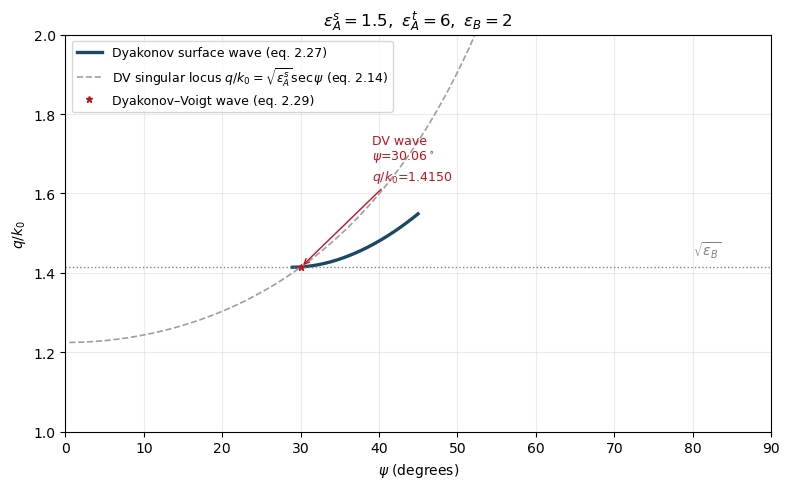

In [5]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(psi_deg, q_dyak, lw=2.4, color="#1b4965", label="Dyakonov surface wave (eq. 2.27)")
ax.plot(psi_deg, q_DV_line(np.deg2rad(psi_deg)), "--", lw=1.2, color="#9aa0a6",
        label=r"DV singular locus $q/k_0=\sqrt{\varepsilon_A^s}\sec\psi$ (eq. 2.14)")
ax.plot([psi_DV],[q_DV], "*", ms=5, color="#c1121f", zorder=5,
        label="Dyakonov–Voigt wave (eq. 2.29)")
ax.annotate(f"DV wave\n$\\psi$={psi_DV:.2f}$^\\circ$\n$q/k_0$={q_DV:.4f}",
            xy=(psi_DV,q_DV), xytext=(psi_DV+9,q_DV+0.22),
            arrowprops=dict(arrowstyle="->",color="#c1121f"), color="#c1121f", fontsize=9)
ax.axhline(np.sqrt(eps_B), ls=":", color="gray", lw=1)
ax.text(80, np.sqrt(eps_B)+0.03, r"$\sqrt{\varepsilon_B}$", color="gray")
ax.set_xlim(0,90); ax.set_ylim(1,2)
ax.set_xlabel(r"$\psi$ (degrees)"); ax.set_ylabel(r"$q/k_0$")
ax.set_title(r"$\varepsilon_A^s=1.5,\ \varepsilon_A^t=6,\ \varepsilon_B=2$")
ax.legend(loc="upper left", fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## What the picture says

The DV wave is **not a separate dispersion curve** — for fixed permittivities it is one point. It sits precisely at the intersection of the Dyakonov branch with the singular locus $q/k_0=\sqrt{\varepsilon_A^s}\sec\psi$, i.e. where the two medium-$\mathcal A$ eigenvalues coalesce ($\alpha_{A1}=\alpha_{A2}$) and $[P_A]$ stops being diagonalisable. There the field in $\mathcal A$ picks up the linear-$\times$-exponential $z$-dependence of eq. (2.19) — the Voigt character. One can verify numerically that the Dyakonov residual has a *double* root on the locus at exactly this angle, and that the angle equals the eq.-(2.29) / eq.-(2.48) solution to ~$10^{-9}$ degrees.

To explore: changing `eps_t` slides the DV point along the locus (larger `eps_t` $\to$ smaller $\psi_{\rm DV}$); the constraints (2.35) require `eps_t - eps_s > 2 eps_B` and `eps_B > eps_s`, both satisfied here.